In [1]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully!")

Mounted at /content/drive
Google Drive connected successfully!


In [2]:
from pathlib import Path

zip_files = list(Path("/content/drive/MyDrive").glob("*.zip"))

for f in zip_files:
    print(f)

/content/drive/MyDrive/Expiry Date.v6-version2.yolov8 (3).zip
/content/drive/MyDrive/flipkart grid.v1i.yolov8.zip
/content/drive/MyDrive/detect.v1i.yolov11 (2).zip
/content/drive/MyDrive/data.zip
/content/drive/MyDrive/Expiry Date.v6-version2.yolov11 (3).zip
/content/drive/MyDrive/archive (4).zip
/content/drive/MyDrive/archive (3).zip
/content/drive/MyDrive/brand_type_flavour.zip
/content/drive/MyDrive/brand-20250416T161557Z-001.zip
/content/drive/MyDrive/Solar Panel Fault Dataset New.v2i.yolov8.zip


In [3]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/Solar Panel Fault Dataset New.v2i.yolov8.zip")
extract_path = Path("/content/solar_dataset")

# Create extraction folder
extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction completed!")
print("Dataset location:", extract_path)

✅ Extraction completed!
Dataset location: /content/solar_dataset


In [4]:
from pathlib import Path

base = Path("/content/solar_dataset")

print("data.yaml:", (base / "data.yaml").exists())
print("train:", (base / "train").exists())
print("valid:", (base / "valid").exists())
print("test:", (base / "test").exists())

data.yaml: True
train: True
valid: True
test: True


In [5]:
from pathlib import Path
import yaml

data_yaml = Path("/content/solar_dataset/data.yaml")

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print("=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)

print("Train :", data.get("train"))
print("Val   :", data.get("val"))
print("Test  :", data.get("test"))
print("NC    :", data.get("nc"))
print("Names :", data.get("names"))

print("\nClass count:", len(data.get("names", [])))

assert data.get("nc") == len(data.get("names", [])), \
    "❌ nc does not match number of class names"

print("✅ data.yaml class configuration is consistent")

DATASET CONFIGURATION
Train : ../train/images
Val   : ../valid/images
Test  : ../test/images
NC    : 6
Names : ['Bird Drop', 'Defective', 'Dusty', 'Non Defective', 'Physical Damage', 'Snow']

Class count: 6
✅ data.yaml class configuration is consistent


In [6]:
from pathlib import Path

base = Path("/content/solar_dataset")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = base / split / "images"
    label_dir = base / split / "labels"

    images = {
        p.stem for p in image_dir.iterdir()
        if p.suffix.lower() in image_exts
    }

    labels = {p.stem for p in label_dir.glob("*.txt")}

    missing_labels = images - labels
    missing_images = labels - images

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(missing_images))

    if missing_labels:
        print("Example missing labels:", list(missing_labels)[:3])

    if missing_images:
        print("Example missing images:", list(missing_images)[:3])


===== TRAIN =====
Images: 7669
Labels: 7669
Images without labels: 0
Labels without images: 0

===== VALID =====
Images: 611
Labels: 611
Images without labels: 0
Labels without images: 0

===== TEST =====
Images: 450
Labels: 450
Images without labels: 0
Labels without images: 0


In [7]:
from pathlib import Path
from collections import Counter

base = Path("/content/solar_dataset")

for split in ["train", "valid", "test"]:
    label_dir = base / split / "labels"
    stats = Counter()

    for p in label_dir.glob("*.txt"):
        lines = [x.strip() for x in p.read_text(errors="ignore").splitlines() if x.strip()]

        types = []

        for line in lines:
            n = len(line.split())

            if n == 5:
                types.append("detection")
            elif n > 5 and (n - 1) % 2 == 0:
                types.append("segmentation")
            else:
                types.append("malformed")

        kinds = set(types)

        if kinds == {"detection"}:
            stats["detection_only"] += 1
        elif kinds == {"segmentation"}:
            stats["segmentation_only"] += 1
        elif "detection" in kinds and "segmentation" in kinds:
            stats["mixed"] += 1
        elif "malformed" in kinds:
            stats["malformed"] += 1
        elif not kinds:
            stats["empty"] += 1

    print(f"\n===== {split.upper()} =====")
    for category, count in stats.items():
        print(f"{category:20s}: {count}")


===== TRAIN =====
detection_only      : 4114
mixed               : 2023
segmentation_only   : 1532

===== VALID =====
segmentation_only   : 185
mixed               : 235
detection_only      : 191

===== TEST =====
mixed               : 89
detection_only      : 260
segmentation_only   : 101


In [8]:
from pathlib import Path
import shutil

src = Path("/content/solar_dataset")
dst = Path("/content/solar_detection_dataset")

# Remove previous corrected copy if it exists
if dst.exists():
    shutil.rmtree(dst)

for split in ["train", "valid", "test"]:
    image_src = src / split / "images"
    label_src = src / split / "labels"

    image_dst = dst / split / "images"
    label_dst = dst / split / "labels"

    image_dst.mkdir(parents=True, exist_ok=True)
    label_dst.mkdir(parents=True, exist_ok=True)

    # Copy images
    for img in image_src.iterdir():
        if img.is_file():
            shutil.copy2(img, image_dst / img.name)

    detection_objects = 0
    converted_objects = 0
    invalid_objects = 0

    for label_file in label_src.glob("*.txt"):
        output = []

        for line in label_file.read_text(errors="ignore").splitlines():
            values = line.strip().split()

            if not values:
                continue

            # YOLO detection format
            if len(values) == 5:
                try:
                    cls, xc, yc, w, h = map(float, values)

                    if 0 <= cls < 6 and w > 0 and h > 0:
                        output.append(
                            f"{int(cls)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"
                        )
                        detection_objects += 1
                    else:
                        invalid_objects += 1
                except:
                    invalid_objects += 1

            # YOLO segmentation format
            elif len(values) > 5 and (len(values) - 1) % 2 == 0:
                try:
                    cls = int(float(values[0]))
                    coords = list(map(float, values[1:]))

                    xs = coords[0::2]
                    ys = coords[1::2]

                    xmin = max(0.0, min(xs))
                    xmax = min(1.0, max(xs))
                    ymin = max(0.0, min(ys))
                    ymax = min(1.0, max(ys))

                    xc = (xmin + xmax) / 2
                    yc = (ymin + ymax) / 2
                    w = xmax - xmin
                    h = ymax - ymin

                    if 0 <= cls < 6 and w > 0 and h > 0:
                        output.append(
                            f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"
                        )
                        converted_objects += 1
                    else:
                        invalid_objects += 1

                except:
                    invalid_objects += 1

            else:
                invalid_objects += 1

        (label_dst / label_file.name).write_text(
            "\n".join(output) + ("\n" if output else "")
        )

    print(f"\n===== {split.upper()} =====")
    print("Existing detection objects :", detection_objects)
    print("Converted polygon objects  :", converted_objects)
    print("Invalid objects            :", invalid_objects)
    print("Total usable objects       :", detection_objects + converted_objects)

# Create corrected data.yaml
names = [
    "Bird Drop",
    "Defective",
    "Dusty",
    "Non Defective",
    "Physical Damage",
    "Snow"
]

yaml_text = f"""train: /content/solar_detection_dataset/train/images
val: /content/solar_detection_dataset/valid/images
test: /content/solar_detection_dataset/test/images

nc: 6
names: {names}
"""

(dst / "data.yaml").write_text(yaml_text)

print("\n" + "=" * 60)
print("✅ CORRECTED DATASET CREATED")
print("=" * 60)
print(dst)
print(dst / "data.yaml")


===== TRAIN =====
Existing detection objects : 28210
Converted polygon objects  : 12804
Invalid objects            : 0
Total usable objects       : 41014

===== VALID =====
Existing detection objects : 1944
Converted polygon objects  : 1509
Invalid objects            : 0
Total usable objects       : 3453

===== TEST =====
Existing detection objects : 1981
Converted polygon objects  : 815
Invalid objects            : 0
Total usable objects       : 2796

✅ CORRECTED DATASET CREATED
/content/solar_detection_dataset
/content/solar_detection_dataset/data.yaml


In [9]:
from pathlib import Path

base = Path("/content/solar_detection_dataset")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = base / split / "images"
    label_dir = base / split / "labels"

    images = {
        p.stem for p in image_dir.iterdir()
        if p.suffix.lower() in image_exts
    }
    labels = {p.stem for p in label_dir.glob("*.txt")}

    invalid = 0
    total_objects = 0

    for p in label_dir.glob("*.txt"):
        for line in p.read_text(errors="ignore").splitlines():
            v = line.split()

            if len(v) != 5:
                invalid += 1
                continue

            try:
                cls, xc, yc, w, h = map(float, v)

                if not (0 <= cls < 6):
                    invalid += 1
                elif not all(0 <= x <= 1 for x in [xc, yc, w, h]):
                    invalid += 1
                elif w <= 0 or h <= 0:
                    invalid += 1
                else:
                    total_objects += 1
            except:
                invalid += 1

    print(f"\n===== {split.upper()} =====")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Missing labels:", len(images - labels))
    print("Missing images:", len(labels - images))
    print("Invalid rows:", invalid)
    print("Valid objects:", total_objects)


===== TRAIN =====
Images: 7669
Labels: 7669
Missing labels: 0
Missing images: 0
Invalid rows: 0
Valid objects: 41014

===== VALID =====
Images: 611
Labels: 611
Missing labels: 0
Missing images: 0
Invalid rows: 0
Valid objects: 3453

===== TEST =====
Images: 450
Labels: 450
Missing labels: 0
Missing images: 0
Invalid rows: 0
Valid objects: 2796


In [10]:
from pathlib import Path
from collections import Counter

base = Path("/content/solar_detection_dataset")

class_names = [
    "Bird Drop",
    "Defective",
    "Dusty",
    "Non Defective",
    "Physical Damage",
    "Snow"
]

for split in ["train", "valid", "test"]:
    counts = Counter()

    for label_file in (base / split / "labels").glob("*.txt"):
        for line in label_file.read_text(errors="ignore").splitlines():
            values = line.split()

            if len(values) == 5:
                cls = int(float(values[0]))
                counts[cls] += 1

    print(f"\n===== {split.upper()} CLASS DISTRIBUTION =====")

    total = sum(counts.values())

    for cls_id, name in enumerate(class_names):
        count = counts[cls_id]
        percentage = (count / total * 100) if total else 0
        print(f"{cls_id}: {name:20s} {count:6d} ({percentage:5.2f}%)")

    print(f"TOTAL OBJECTS: {total}")


===== TRAIN CLASS DISTRIBUTION =====
0: Bird Drop              6859 (16.72%)
1: Defective              6969 (16.99%)
2: Dusty                  6799 (16.58%)
3: Non Defective          6863 (16.73%)
4: Physical Damage        6878 (16.77%)
5: Snow                   6646 (16.20%)
TOTAL OBJECTS: 41014

===== VALID CLASS DISTRIBUTION =====
0: Bird Drop               503 (14.57%)
1: Defective               667 (19.32%)
2: Dusty                   576 (16.68%)
3: Non Defective           592 (17.14%)
4: Physical Damage         562 (16.28%)
5: Snow                    553 (16.02%)
TOTAL OBJECTS: 3453

===== TEST CLASS DISTRIBUTION =====
0: Bird Drop               478 (17.10%)
1: Defective               478 (17.10%)
2: Dusty                   458 (16.38%)
3: Non Defective           458 (16.38%)
4: Physical Damage         462 (16.52%)
5: Snow                    462 (16.52%)
TOTAL OBJECTS: 2796


In [11]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("❌ GPU NOT AVAILABLE")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [14]:
from ultralytics import RTDETR
import os

# Paths
DATA = "/content/solar_detection_dataset/data.yaml"
PROJECT = "/content/drive/MyDrive/solar_training"
RUN_NAME = "rtdetr_l_solar_final"

RUN_DIR = os.path.join(PROJECT, RUN_NAME)
LAST = os.path.join(RUN_DIR, "weights", "last.pt")

# Resume if checkpoint exists, otherwise start fresh
if os.path.exists(LAST):
    print("✅ Checkpoint found — RESUMING training")
    print(LAST)

    model = RTDETR(LAST)

    model.train(
        resume=True
    )

else:
    print("🆕 No checkpoint found — STARTING training from pretrained RT-DETR-L")

    model = RTDETR("rtdetr-l.pt")

    model.train(
        data=DATA,
        imgsz=640,
        epochs=20,
        batch=8,
        device=0,
        seed=42,
        deterministic=False,
        patience=100,
        workers=2,
        amp=True,

        project=PROJECT,
        name=RUN_NAME,
        exist_ok=True,

        save=True,
        save_period=1,
        plots=True
    )

print("\n✅ TRAINING COMMAND FINISHED")
print("Run directory:", RUN_DIR)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
🆕 No checkpoint found — STARTING training from pretrained RT-DETR-L
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_detection_dataset/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasi

In [13]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.7 MB/s eta 0:00:00


In [15]:
from google.colab import files

BEST = "/content/drive/MyDrive/solar_training/rtdetr_l_solar_final/weights/best.pt"

files.download(BEST)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from ultralytics import RTDETR

MODEL = "/content/drive/MyDrive/solar_training/rtdetr_l_solar_final/weights/best.pt"
DATA = "/content/solar_detection_dataset/data.yaml"

model = RTDETR(MODEL)

metrics = model.val(
    data=DATA,
    split="test",
    imgsz=640,
    plots=True
)

print("\n========== TEST RESULTS ==========")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary (fused): 315 layers, 31,996,070 parameters, 0 gradients, 105.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 31.5±12.6 MB/s, size: 81.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/solar_detection_dataset/test/labels... 450 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 450/450 547.3it/s 0.8s
val: New cache created: /content/solar_detection_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.2it/s 23.5s
                   all        450       2796      0.442      0.514      0.424      0.271
             Bird Drop         53        478      0.502      0.247      0.282     0.0926
             Defective        240        478      0.432      0.697    

In [18]:
from ultralytics import RTDETR

MODEL = "/content/drive/MyDrive/solar_training/rtdetr_l_solar_final/weights/best.pt"

model = RTDETR(MODEL)

results = model.predict(
    source="real_solar.jpg",
    imgsz=640,
    conf=0.25,
    save=True
)

print("Prediction completed.")

FileNotFoundError: real_solar.jpg does not exist

In [19]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-13 143720.png to Screenshot 2026-09-13 143720.png


In [20]:
from ultralytics import RTDETR

MODEL = "/content/drive/MyDrive/solar_training/rtdetr_l_solar_final/weights/best.pt"
IMAGE = "/content/Screenshot 2026-09-13 143720.png"

model = RTDETR(MODEL)

results = model.predict(
    source=IMAGE,
    imgsz=640,
    conf=0.25,
    save=True
)

print("Prediction completed.")


image 1/1 /content/Screenshot 2026-09-13 143720.png: 640x640 2 Defectives, 7 Non Defectives, 3 Physical Damages, 101.8ms
Speed: 2.4ms preprocess, 101.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction completed.


['/content/runs/detect/predict/Screenshot 2026-09-13 143720.jpg']


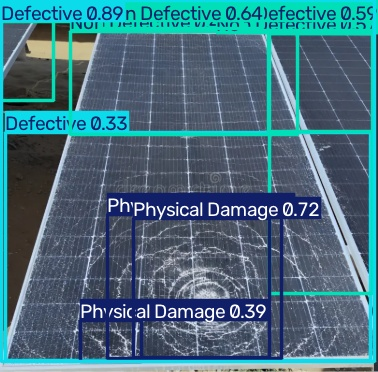

In [21]:
from IPython.display import Image, display
import glob

predicted_files = glob.glob("/content/runs/detect/predict/*")

print(predicted_files)

display(Image(filename=predicted_files[0]))

In [22]:
results = model.predict(
    source="/content/Screenshot 2026-09-13 143720.png",
    imgsz=640,
    conf=0.50,
    save=True
)

print("Prediction completed.")


image 1/1 /content/Screenshot 2026-09-13 143720.png: 640x640 1 Defective, 3 Non Defectives, 2 Physical Damages, 83.3ms
Speed: 1.8ms preprocess, 83.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction completed.


/content/runs/detect/predict/Screenshot 2026-09-13 143720.jpg


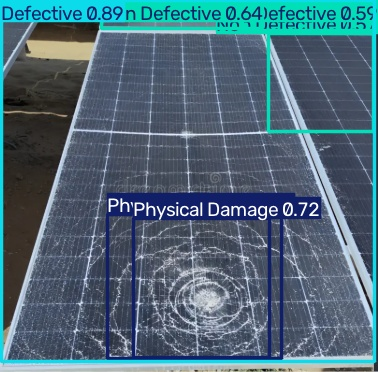

In [23]:
from IPython.display import Image, display
import glob

predicted_files = glob.glob("/content/runs/detect/predict*/*")

print(predicted_files[-1])

display(Image(filename=predicted_files[-1]))